# ライブラリのインポート

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lingam
import networkx as nx

# ダミーデータの作成

In [4]:
### 1000行×3列の作成
### LiNGAMはデータの非ガウス性を利用するため、今回は誤差項をラプラス分布から生成する

In [5]:
np.random.seed(42)

n = 1000

# 独立な非ガウス誤差
e1 = np.random.laplace(0, 1, n)
e2 = np.random.laplace(0, 1, n)
e3 = np.random.laplace(0, 1, n)

# 真の因果構造に従ってデータを生成
X1 = e1
X2 = 2.0 * X1 + e2
X3 = 1.0 * X1 + 3.0 * X2 + e3

df = pd.DataFrame({
    "X1": X1,
    "X2": X2,
    "X3": X3
})

df.head()

,X1,X2,X3
0,-0.288909,-1.571352,-5.650354
1,2.316974,4.721471,15.776082
2,0.623599,2.617192,10.149199
3,0.219795,1.064051,2.716985
4,-1.164633,-1.379619,-5.912479


In [7]:
### X1 = e1
### X2 = 2×X1 + e2
### X3 = 1×X1 + 3×X2 + e3
### の関係にあるデータセットを作成(ただしこの情報をLiNGAMには渡さない)

# データの確認

In [8]:
df.describe()

,X1,X2,X3
count,1000.000000,1000.000000,1000.000000
mean,-0.039646,-0.040185,-0.178499
std,1.376077,3.159269,10.906424
min,-4.681614,-11.486416,-39.857271
25%,-0.750932,-1.826297,-6.370823
50%,-0.006406,-0.042811,-0.039856
75%,0.670683,1.805327,5.835833
max,7.479298,15.207914,54.172887


In [9]:
df.corr()

,X1,X2,X3
X1,1.000000,0.891535,0.907125
X2,0.891535,1.000000,0.989406
X3,0.907125,0.989406,1.000000


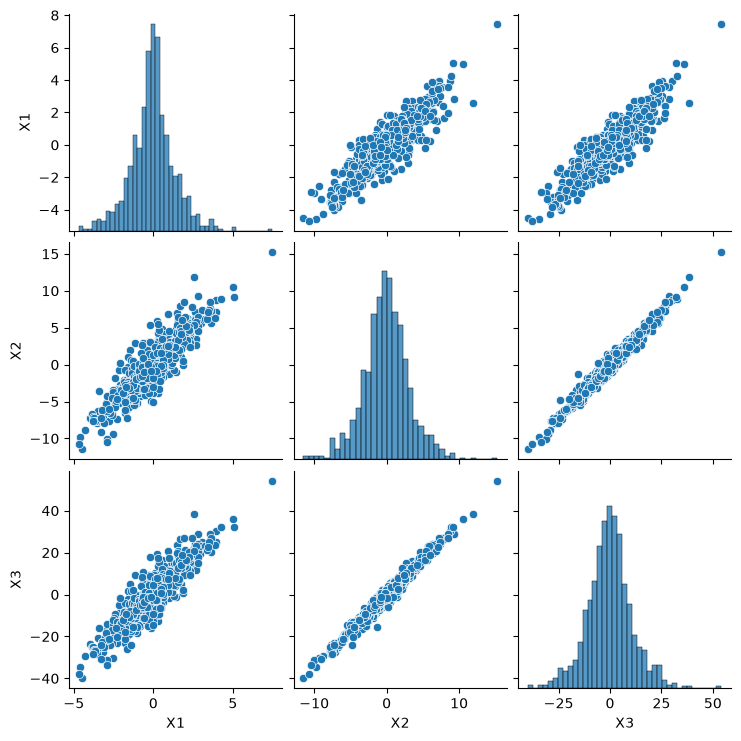

In [10]:
sns.pairplot(df)
plt.show()

# LiNGAMの実行

In [11]:
model = lingam.DirectLiNGAM()
model.fit(df)

In [12]:
model.causal_order_

[np.int64(0), np.int64(1), np.int64(2)]

In [13]:
model.adjacency_matrix_

array([[0.        , 0.        , 0.        ],
       [2.04683215, 0.        , 0.        ],
       [0.96711232, 3.04007336, 0.        ]])

In [ ]:
### 行を結果、列を原因として見る。
### すなわち今回LiNGAMは
### X1 → X2 (2.04)
### X1 → X3 (0.97)
### X2 → X3 (3.04)
### と判断したことになる

In [17]:
# 大した意味はないが表にする
adj = pd.DataFrame(
    model.adjacency_matrix_,
    index=df.columns,
    columns=df.columns
)

adj

,X1,X2,X3
X1,0.000000,0.000000,0.0
X2,2.046832,0.000000,0.0
X3,0.967112,3.040073,0.0


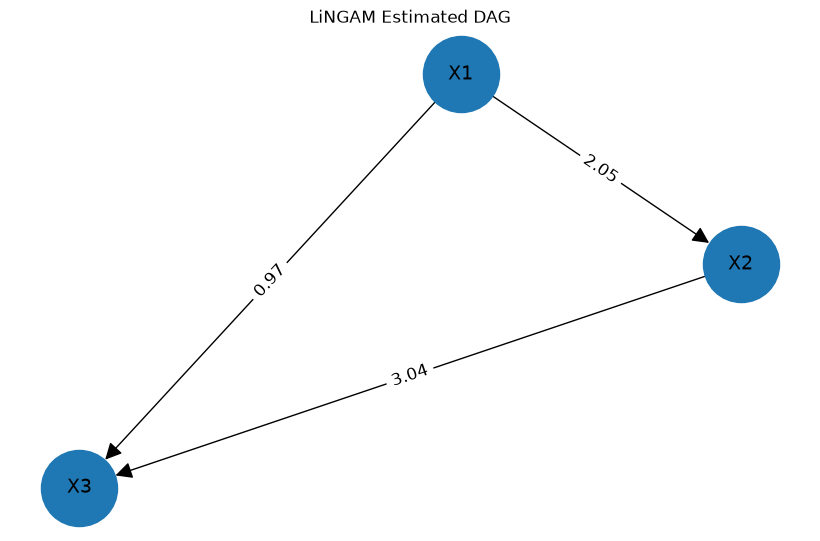

In [18]:
# LiNGAMの推定結果
adj = model.adjacency_matrix_
columns = df.columns

G = nx.DiGraph()

# adjacency_matrix_[i, j] は j → i
for i in range(len(columns)):
    for j in range(len(columns)):
        weight = adj[i, j]

        if weight != 0:
            G.add_edge(
                columns[j],
                columns[i],
                weight=weight
            )

# 配置
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(8, 5))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    font_size=14,
    arrowsize=25
)

# 推定係数も自動取得
edge_labels = {
    (u, v): f"{d['weight']:.2f}"
    for u, v, d in G.edges(data=True)
}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=12
)

plt.title("LiNGAM Estimated DAG")
plt.axis("off")
plt.show()

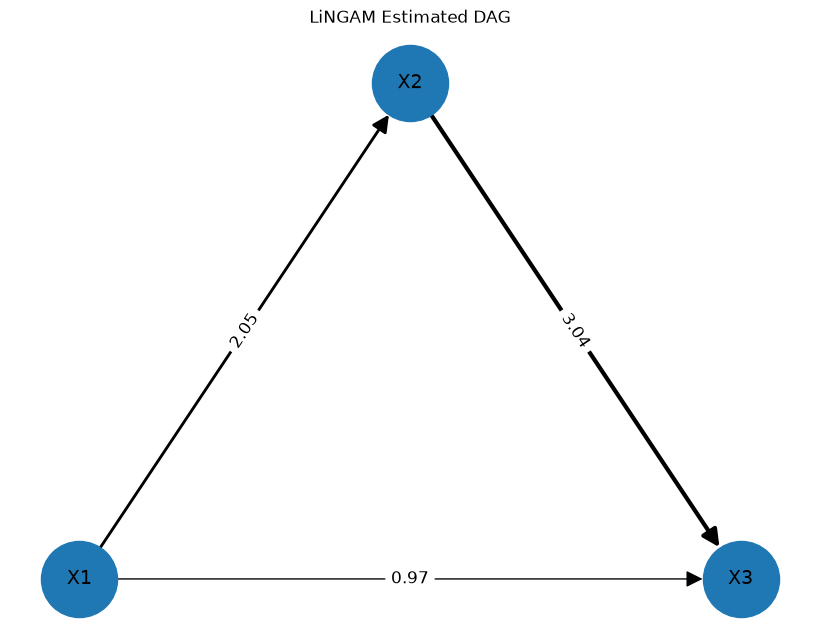

In [19]:
adj = model.adjacency_matrix_
columns = df.columns

G = nx.DiGraph()

for target in range(len(columns)):
    for source in range(len(columns)):
        weight = adj[target, source]

        if abs(weight) > 0.01:
            G.add_edge(
                columns[source],
                columns[target],
                weight=weight
            )

# 正三角形に近い配置
pos = {
    "X1": (0, 0),
    "X2": (1, 1.732),
    "X3": (2, 0)
}

# 係数の絶対値を線の太さにする
widths = [
    abs(data["weight"])
    for _, _, data in G.edges(data=True)
]

plt.figure(figsize=(8, 6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    font_size=14,
    arrowsize=25,
    width=widths
)

# 係数を表示
edge_labels = {
    (u, v): f"{data['weight']:.2f}"
    for u, v, data in G.edges(data=True)
}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=12
)

plt.title("LiNGAM Estimated DAG")
plt.axis("off")
plt.show()